In [1]:
import os
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb

In [2]:
DataSetListingPath = r'C:\Users\w\Desktop\real_estate_rag_ecosystem\data\raw\listings.csv'

df = pd.read_csv(DataSetListingPath)

df.head()

,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,review_scores_value,requires_license,license,jurisdiction_names,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,241032,https://www.airbnb.com/rooms/241032,20160104002432,2016-01-04,Stylish Queen Anne Apartment,NaN,Make your self at home in this charming one-be...,Make your self at home in this charming one-be...,none,NaN,...,10.0,f,NaN,WASHINGTON,f,moderate,f,f,2,4.07
1,953595,https://www.airbnb.com/rooms/953595,20160104002432,2016-01-04,Bright & Airy Queen Anne Apartment,Chemically sensitive? We've removed the irrita...,"Beautiful, hypoallergenic apartment in an extr...",Chemically sensitive? We've removed the irrita...,none,"Queen Anne is a wonderful, truly functional vi...",...,10.0,f,NaN,WASHINGTON,f,strict,t,t,6,1.48
2,3308979,https://www.airbnb.com/rooms/3308979,20160104002432,2016-01-04,New Modern House-Amazing water view,New modern house built in 2013. Spectacular s...,"Our house is modern, light and fresh with a wa...",New modern house built in 2013. Spectacular s...,none,Upper Queen Anne is a charming neighborhood fu...,...,10.0,f,NaN,WASHINGTON,f,strict,f,f,2,1.15
3,7421966,https://www.airbnb.com/rooms/7421966,20160104002432,2016-01-04,Queen Anne Chateau,A charming apartment that sits atop Queen Anne...,NaN,A charming apartment that sits atop Queen Anne...,none,NaN,...,NaN,f,NaN,WASHINGTON,f,flexible,f,f,1,NaN
4,278830,https://www.airbnb.com/rooms/278830,20160104002432,2016-01-04,Charming craftsman 3 bdm house,Cozy family craftman house in beautiful neighb...,Cozy family craftman house in beautiful neighb...,Cozy family craftman house in beautiful neighb...,none,We are in the beautiful neighborhood of Queen ...,...,9.0,f,NaN,WASHINGTON,f,strict,f,f,1,0.89


In [3]:
df.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'name', 'summary',
       'space', 'description', 'experiences_offered', 'neighborhood_overview',
       'notes', 'transit', 'thumbnail_url', 'medium_url', 'picture_url',
       'xl_picture_url', 'host_id', 'host_url', 'host_name', 'host_since',
       'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood',
       'host_listings_count', 'host_total_listings_count',
       'host_verifications', 'host_has_profile_pic', 'host_identity_verified',
       'street', 'neighbourhood', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'city', 'state', 'zipcode', 'market',
       'smart_location', 'country_code', 'country', 'latitude', 'longitude',
       'is_location_exact', 'property_type', 'room_type', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'bed_type', 'amenities', '

In [4]:
columns_to_keep = [
    'price', 'space', 'experiences_offered', 'street', 'neighbourhood', 
    'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'city', 
    'state', 'zipcode', 'market', 'smart_location', 'country', 
    'latitude', 'longitude', 'property_type', 'room_type', 'accommodates',
    'bathrooms', 'bedrooms', 'beds', 'bed_type', 'amenities', 'square_feet',
    'security_deposit', 'cleaning_fee', 'guests_included', 'extra_people',
    'number_of_reviews', 'review_scores_rating', 'reviews_per_month',
    'host_is_superhost', 'host_listings_count', 'host_total_listings_count'
]


df_pp = df[columns_to_keep].copy()

df_pp.head()

,price,space,experiences_offered,street,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,city,state,zipcode,...,security_deposit,cleaning_fee,guests_included,extra_people,number_of_reviews,review_scores_rating,reviews_per_month,host_is_superhost,host_listings_count,host_total_listings_count
0,$85.00,Make your self at home in this charming one-be...,none,"Gilman Dr W, Seattle, WA 98119, United States",Queen Anne,West Queen Anne,Queen Anne,Seattle,WA,98119,...,NaN,NaN,2,$5.00,207,95.0,4.07,f,3.0,3.0
1,$150.00,"Beautiful, hypoallergenic apartment in an extr...",none,"7th Avenue West, Seattle, WA 98119, United States",Queen Anne,West Queen Anne,Queen Anne,Seattle,WA,98119,...,$100.00,$40.00,1,$0.00,43,96.0,1.48,t,6.0,6.0
2,$975.00,"Our house is modern, light and fresh with a wa...",none,"West Lee Street, Seattle, WA 98119, United States",Queen Anne,West Queen Anne,Queen Anne,Seattle,WA,98119,...,"$1,000.00",$300.00,10,$25.00,20,97.0,1.15,f,2.0,2.0
3,$100.00,NaN,none,"8th Avenue West, Seattle, WA 98119, United States",Queen Anne,West Queen Anne,Queen Anne,Seattle,WA,98119,...,NaN,NaN,1,$0.00,0,NaN,NaN,f,1.0,1.0
4,$450.00,Cozy family craftman house in beautiful neighb...,none,"14th Ave W, Seattle, WA 98119, United States",Queen Anne,West Queen Anne,Queen Anne,Seattle,WA,98119,...,$700.00,$125.00,6,$15.00,38,92.0,0.89,f,2.0,2.0


In [5]:
for col in df_pp.columns:
    unique_values = df_pp[col].unique() # .dropna() ignores the NaNs for this check
    num_unique = len(unique_values)
    
    print(f"--- Column: {col} ---")
    print(f"Data Type: {df_pp[col].dtype}")
    print(f"Total Unique Values: {num_unique}")
    
    # If there are fewer than 15 unique values, print them all (Great for categories)
    if num_unique <= 15:
        print(f"Values: {unique_values}\n")
    # If there are a lot, just print the first 10 (Great for continuous numbers/text)
    else:
        print(f"Sample Values: {unique_values[:10]} ...\n")

--- Column: price ---
Data Type: object
Total Unique Values: 273
Sample Values: ['$85.00' '$150.00' '$975.00' '$100.00' '$450.00' '$120.00' '$80.00'
 '$60.00' '$90.00' '$95.00'] ...

--- Column: space ---
Data Type: object
Total Unique Values: 3120
Sample Values: ["Make your self at home in this charming one-bedroom apartment, centrally-located on the west side of Queen Anne hill.   This elegantly-decorated, completely private apartment (bottom unit of a duplex) has an open floor plan, bamboo floors, a fully equipped kitchen, a TV,  DVD player, basic cable, and a very cozy bedroom with a queen-size bed. The unit sleeps up to four (two in the bedroom and two on the very comfortable fold out couch, linens included) and includes free WiFi and laundry. The apartment opens onto a private deck, complete with it's own BBQ, overlooking a garden and a forest of black bamboo.    The Apartment is perfectly-located just one block from the bus lines where you can catch a bus and be downtown Seattle

In [6]:
columns_to_keep_cleansed = [
    'price', 'neighbourhood_group_cleansed',
    'latitude', 'longitude', 'property_type', 'room_type', 'accommodates',
    'bathrooms', 'bedrooms', 'beds', 'bed_type', 'amenities', 'square_feet',
    'security_deposit', 'cleaning_fee', 'guests_included', 'extra_people',
    'number_of_reviews', 'review_scores_rating', 'reviews_per_month',
    'host_is_superhost', 'host_listings_count', 'host_total_listings_count'
]

df_pp = df[columns_to_keep_cleansed].copy()

with pd.option_context('display.max_columns', None):
    display(df_pp.head())

,price,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,bed_type,amenities,square_feet,security_deposit,cleaning_fee,guests_included,extra_people,number_of_reviews,review_scores_rating,reviews_per_month,host_is_superhost,host_listings_count,host_total_listings_count
0,$85.00,Queen Anne,47.636289,-122.371025,Apartment,Entire home/apt,4,1.0,1.0,1.0,Real Bed,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",NaN,NaN,NaN,2,$5.00,207,95.0,4.07,f,3.0,3.0
1,$150.00,Queen Anne,47.639123,-122.365666,Apartment,Entire home/apt,4,1.0,1.0,1.0,Real Bed,"{TV,Internet,""Wireless Internet"",Kitchen,""Free...",NaN,$100.00,$40.00,1,$0.00,43,96.0,1.48,t,6.0,6.0
2,$975.00,Queen Anne,47.629724,-122.369483,House,Entire home/apt,11,4.5,5.0,7.0,Real Bed,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",NaN,"$1,000.00",$300.00,10,$25.00,20,97.0,1.15,f,2.0,2.0
3,$100.00,Queen Anne,47.638473,-122.369279,Apartment,Entire home/apt,3,1.0,0.0,2.0,Real Bed,"{Internet,""Wireless Internet"",Kitchen,""Indoor ...",NaN,NaN,NaN,1,$0.00,0,NaN,NaN,f,1.0,1.0
4,$450.00,Queen Anne,47.632918,-122.372471,House,Entire home/apt,6,2.0,3.0,3.0,Real Bed,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",NaN,$700.00,$125.00,6,$15.00,38,92.0,0.89,f,2.0,2.0


In [7]:
df_pp.shape

(3818, 23)

In [8]:
df_pp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3818 entries, 0 to 3817
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   price                         3818 non-null   object 
 1   neighbourhood_group_cleansed  3818 non-null   object 
 2   latitude                      3818 non-null   float64
 3   longitude                     3818 non-null   float64
 4   property_type                 3817 non-null   object 
 5   room_type                     3818 non-null   object 
 6   accommodates                  3818 non-null   int64  
 7   bathrooms                     3802 non-null   float64
 8   bedrooms                      3812 non-null   float64
 9   beds                          3817 non-null   float64
 10  bed_type                      3818 non-null   object 
 11  amenities                     3818 non-null   object 
 12  square_feet                   97 non-null     float64
 13  sec

In [9]:
df_pp.isnull().sum()

price                              0
neighbourhood_group_cleansed       0
latitude                           0
longitude                          0
property_type                      1
room_type                          0
accommodates                       0
bathrooms                         16
bedrooms                           6
beds                               1
bed_type                           0
amenities                          0
square_feet                     3721
security_deposit                1952
cleaning_fee                    1030
guests_included                    0
extra_people                       0
number_of_reviews                  0
review_scores_rating             647
reviews_per_month                627
host_is_superhost                  2
host_listings_count                2
host_total_listings_count          2
dtype: int64

In [10]:
df_pp = df_pp.drop(columns=['square_feet'])

df_pp.isnull().sum()

price                              0
neighbourhood_group_cleansed       0
latitude                           0
longitude                          0
property_type                      1
room_type                          0
accommodates                       0
bathrooms                         16
bedrooms                           6
beds                               1
bed_type                           0
amenities                          0
security_deposit                1952
cleaning_fee                    1030
guests_included                    0
extra_people                       0
number_of_reviews                  0
review_scores_rating             647
reviews_per_month                627
host_is_superhost                  2
host_listings_count                2
host_total_listings_count          2
dtype: int64

In [11]:
#security deposite and cleaning fee have a lot of null values but that doesn't mean missing data it means that this
#properties doesn't have cleaning fee or security deposite so we can fill those null values with 0

financial_cols = ['price', 'security_deposit', 'cleaning_fee', 'extra_people']

for col in financial_cols:
    df_pp[col] = df_pp[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)#force it to use replace not regex
    df_pp[col] = pd.to_numeric(df_pp[col], errors='coerce') # errors coerce will turn the value into nan if they can't convert to number

df_pp['security_deposit'] = df_pp['security_deposit'].fillna(0)
df_pp['cleaning_fee'] = df_pp['cleaning_fee'].fillna(0)

df_pp.isnull().sum()

price                             0
neighbourhood_group_cleansed      0
latitude                          0
longitude                         0
property_type                     1
room_type                         0
accommodates                      0
bathrooms                        16
bedrooms                          6
beds                              1
bed_type                          0
amenities                         0
security_deposit                  0
cleaning_fee                      0
guests_included                   0
extra_people                      0
number_of_reviews                 0
review_scores_rating            647
reviews_per_month               627
host_is_superhost                 2
host_listings_count               2
host_total_listings_count         2
dtype: int64

In [12]:
df_pp['reviews_per_month'] = df_pp['reviews_per_month'].fillna(0)

median_rating = df_pp['review_scores_rating'].median()
df_pp['review_scores_rating'] = df_pp['review_scores_rating'].fillna(median_rating)

df_pp.isnull().sum()

price                            0
neighbourhood_group_cleansed     0
latitude                         0
longitude                        0
property_type                    1
room_type                        0
accommodates                     0
bathrooms                       16
bedrooms                         6
beds                             1
bed_type                         0
amenities                        0
security_deposit                 0
cleaning_fee                     0
guests_included                  0
extra_people                     0
number_of_reviews                0
review_scores_rating             0
reviews_per_month                0
host_is_superhost                2
host_listings_count              2
host_total_listings_count        2
dtype: int64

In [13]:
df_pp.dropna(inplace=True)
df_pp.isnull().sum()

price                           0
neighbourhood_group_cleansed    0
latitude                        0
longitude                       0
property_type                   0
room_type                       0
accommodates                    0
bathrooms                       0
bedrooms                        0
beds                            0
bed_type                        0
amenities                       0
security_deposit                0
cleaning_fee                    0
guests_included                 0
extra_people                    0
number_of_reviews               0
review_scores_rating            0
reviews_per_month               0
host_is_superhost               0
host_listings_count             0
host_total_listings_count       0
dtype: int64

In [14]:
df_pp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3793 entries, 0 to 3817
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   price                         3793 non-null   float64
 1   neighbourhood_group_cleansed  3793 non-null   object 
 2   latitude                      3793 non-null   float64
 3   longitude                     3793 non-null   float64
 4   property_type                 3793 non-null   object 
 5   room_type                     3793 non-null   object 
 6   accommodates                  3793 non-null   int64  
 7   bathrooms                     3793 non-null   float64
 8   bedrooms                      3793 non-null   float64
 9   beds                          3793 non-null   float64
 10  bed_type                      3793 non-null   object 
 11  amenities                     3793 non-null   object 
 12  security_deposit              3793 non-null   float64
 13  cleaning

In [15]:
unique_amenities = set()


for row in df_pp['amenities'].dropna():
    
    
    clean_row = str(row).replace('{', '').replace('}', '').replace('"', '').replace("'", "")
    
    
    tokens = clean_row.split(',')
    
    
    for token in tokens:
        clean_token = token.strip()
        
       
        if clean_token:  
            unique_amenities.add(clean_token)


print(f"Total unique amenities found: {len(unique_amenities)}\n")
print("--- Unique Amenities ---")


for amenity in sorted(unique_amenities):
    print(amenity)

Total unique amenities found: 41

--- Unique Amenities ---
24-Hour Check-in
Air Conditioning
Breakfast
Buzzer/Wireless Intercom
Cable TV
Carbon Monoxide Detector
Cat(s)
Dog(s)
Doorman
Dryer
Elevator in Building
Essentials
Family/Kid Friendly
Fire Extinguisher
First Aid Kit
Free Parking on Premises
Gym
Hair Dryer
Hangers
Heating
Hot Tub
Indoor Fireplace
Internet
Iron
Kitchen
Laptop Friendly Workspace
Lock on Bedroom Door
Other pet(s)
Pets Allowed
Pets live on this property
Pool
Safety Card
Shampoo
Smoke Detector
Smoking Allowed
Suitable for Events
TV
Washer
Washer / Dryer
Wheelchair Accessible
Wireless Internet


In [16]:
top_amenities = [
    'Air Conditioning', 
    'Kitchen', 
    'Free Parking on Premises', 
    'Wireless Internet', 
    'Washer', 
    'Dryer', 
    'Hot Tub', 
    'Pool', 
    'Gym', 
    'Indoor Fireplace', 
    'Elevator in Building',
    'Pets Allowed',
    'Family/Kid Friendly',
    'Wheelchair Accessible',
    'TV'
]


for amenity in top_amenities:
    col_name = f"has_{amenity.replace(' ', '_').replace('/', '_')}" # Clean slashes for column names
    df_pp[col_name] = df_pp['amenities'].str.contains(amenity, na=False).astype(int)


df_pp['amenities_count'] = df_pp['amenities'].apply(lambda x: len(str(x).split(',')))


df_pp = df_pp.drop(columns=['amenities'])

with pd.option_context('display.max_columns', None):
    display(df_pp.head())

,price,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,bed_type,security_deposit,cleaning_fee,guests_included,extra_people,number_of_reviews,review_scores_rating,reviews_per_month,host_is_superhost,host_listings_count,host_total_listings_count,has_Air_Conditioning,has_Kitchen,has_Free_Parking_on_Premises,has_Wireless_Internet,has_Washer,has_Dryer,has_Hot_Tub,has_Pool,has_Gym,has_Indoor_Fireplace,has_Elevator_in_Building,has_Pets_Allowed,has_Family_Kid_Friendly,has_Wheelchair_Accessible,has_TV,amenities_count
0,85.0,Queen Anne,47.636289,-122.371025,Apartment,Entire home/apt,4,1.0,1.0,1.0,Real Bed,0.0,0.0,2,5.0,207,95.0,4.07,f,3.0,3.0,1,1,0,1,1,1,0,0,0,0,0,0,1,0,1,10
1,150.0,Queen Anne,47.639123,-122.365666,Apartment,Entire home/apt,4,1.0,1.0,1.0,Real Bed,100.0,40.0,1,0.0,43,96.0,1.48,t,6.0,6.0,0,1,1,1,1,1,0,0,0,0,0,0,1,0,1,16
2,975.0,Queen Anne,47.629724,-122.369483,House,Entire home/apt,11,4.5,5.0,7.0,Real Bed,1000.0,300.0,10,25.0,20,97.0,1.15,f,2.0,2.0,1,1,1,1,1,1,1,0,0,1,0,1,1,0,1,21
3,100.0,Queen Anne,47.638473,-122.369279,Apartment,Entire home/apt,3,1.0,0.0,2.0,Real Bed,0.0,0.0,1,0.0,0,96.0,0.00,f,1.0,1.0,0,1,0,1,1,1,0,0,0,1,0,0,1,0,0,14
4,450.0,Queen Anne,47.632918,-122.372471,House,Entire home/apt,6,2.0,3.0,3.0,Real Bed,700.0,125.0,6,15.0,38,92.0,0.89,f,2.0,2.0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,1,13


In [17]:
df_pp['host_is_superhost'] = df_pp['host_is_superhost'].map({'t': 1, 'f': 0})
df_pp['host_is_superhost'].unique()

array([0, 1], dtype=int64)

In [18]:
categorical_cols = [
    'neighbourhood_group_cleansed', 
    'property_type', 
    'room_type', 
    'bed_type'
]

df_pp = pd.get_dummies(df_pp, columns=categorical_cols, drop_first=True)

df_pp.shape

(3793, 70)

In [19]:
zero_priced_rows_count = 0
for row in df_pp['price']:
    if row < 0:
        zero_priced_rows_count += 1
zero_priced_rows_count

df_pp = df_pp[df_pp['price'] > 0]

In [20]:
Q1 = df_pp['price'].quantile(0.25)
Q3 = df_pp['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outlierRows = 0
for rows in df_pp['price']:
    if rows < lower_bound or rows > upper_bound:
        outlierRows += 1


outlierRows

245

In [21]:
df_pp = df_pp[(df_pp['price'] >= lower_bound) & (df_pp['price'] <= upper_bound)]
print(f"New shape after outlier removal: {df_pp.shape}")
print(f"Price range kept: ${lower_bound:.2f} to ${upper_bound:.2f}")

New shape after outlier removal: (3548, 70)
Price range kept: $-37.50 to $262.50


In [22]:
X = df_pp.drop(columns=['price'])
y = df_pp['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

In [24]:
xgb_model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [25]:
predictions = xgb_model.predict(X_test)

In [26]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mse = mean_squared_error(y_test, predictions)

print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")

Mean Absolute Error (MAE): $22.50
Root Mean Squared Error (RMSE): $30.42


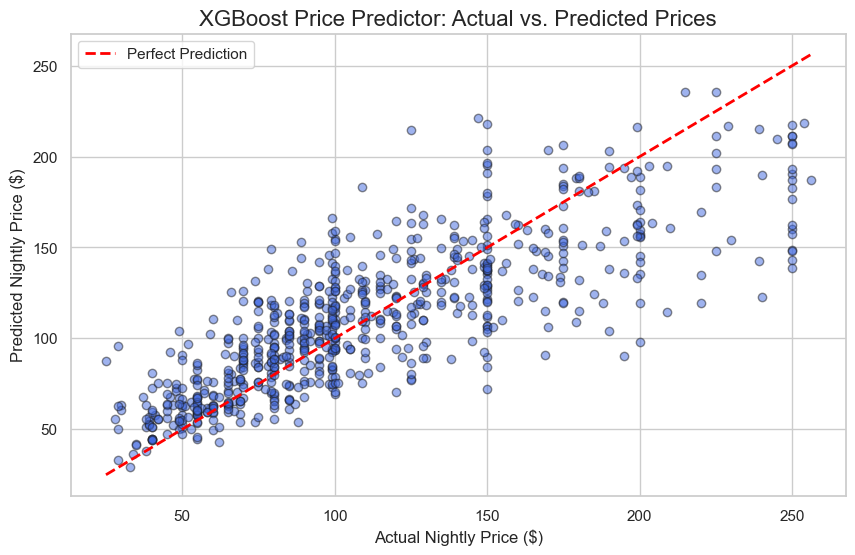

In [27]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.5, color='royalblue', edgecolor='k')


min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('XGBoost Price Predictor: Actual vs. Predicted Prices', fontsize=16)
plt.xlabel('Actual Nightly Price ($)', fontsize=12)
plt.ylabel('Predicted Nightly Price ($)', fontsize=12)
plt.legend()

plt.show()

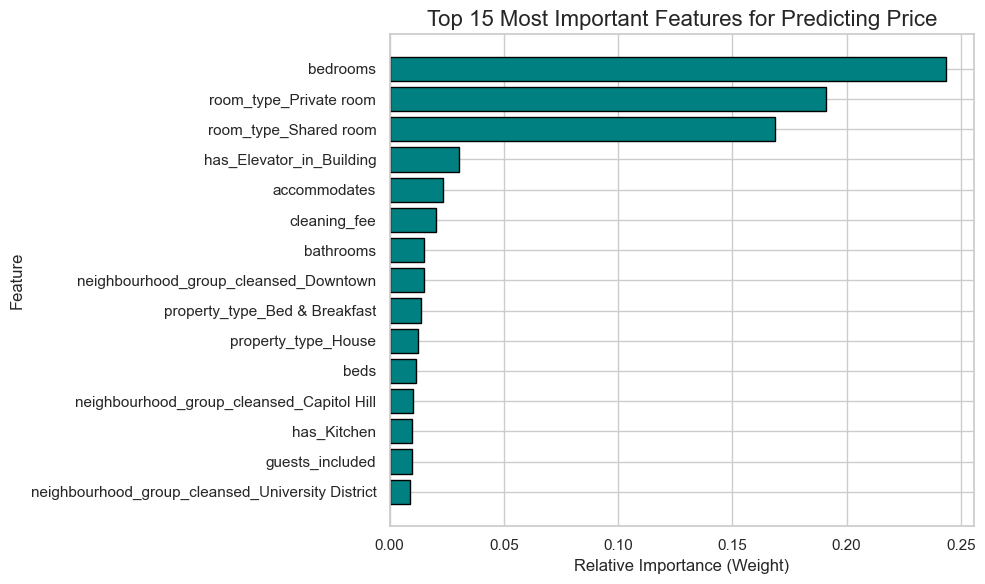


--- Top 5 Feature Weights ---
                 Feature  Importance
                bedrooms    0.243574
  room_type_Private room    0.190777
   room_type_Shared room    0.168848
has_Elevator_in_Building    0.030357
            accommodates    0.023248


In [28]:
importances = xgb_model.feature_importances_

# 3. Create a DataFrame to easily sort and view them
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

# Sort by importance (highest to lowest) and grab the top 15
top_15_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)

# 4. Plot the results
plt.figure(figsize=(10, 6))
# We reverse the order [::-1] so the most important feature is at the top of the chart
plt.barh(top_15_features['Feature'][::-1], top_15_features['Importance'][::-1], color='teal', edgecolor='black')

plt.title('Top 15 Most Important Features for Predicting Price', fontsize=16)
plt.xlabel('Relative Importance (Weight)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

# Print the exact weights for the top 5
print("\n--- Top 5 Feature Weights ---")
print(top_15_features.head(5).to_string(index=False))

In [29]:
df_pp.to_csv('cleaned_airbnb_listings.csv', index=False)

os.makedirs("models", exist_ok=True)

# 2. Save the model to the JSON format you specified earlier
model_path = "models/xgboost_price_model.json"
xgb_model.save_model(model_path)

